# 1.Problem Statement`
Основная цель анализа — выявить закономерности спроса, причины отмен поездок и возможные точки оптимизации работы сервиса.

# 2.Data Loading

In [2]:
#импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# делаем графики более читаемыми
sns.set_style("whitegrid")

In [3]:
#загрузка файла
df = pd.read_csv("ncr_ride_bookings.csv")

In [4]:
#просмотр общего вида датасета
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [5]:
#размер датасета
df.shape

(150000, 21)

Датасет содержит информацию о 150 000 поездках, включая статус поездки, тип автомобиля, точки посадки и высадки, время ожидания, стоимость поездки и рейтинги.

In [6]:
#создал список из названий столбцов
df.columns.tolist()

['Date',
 'Time',
 'Booking ID',
 'Booking Status',
 'Customer ID',
 'Vehicle Type',
 'Pickup Location',
 'Drop Location',
 'Avg VTAT',
 'Avg CTAT',
 'Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Booking Value',
 'Ride Distance',
 'Driver Ratings',
 'Customer Rating',
 'Payment Method']

## Dataset Description

Датасет содержит информацию о поездках сервиса ride-hailing, включая данные о заказе, характеристиках поездки, статусе выполнения, времени ожидания и оценках пользователей.

### Основные идентификаторы

**Date**  
Дата оформления поездки.

**Time**  
Время оформления поездки.

**Booking ID**  
Уникальный идентификатор заказа.

**Customer ID**  
Уникальный идентификатор клиента, оформившего поездку.

---

### Информация о поездке

**Vehicle Type**  
Тип автомобиля, выбранный для поездки.

**Pickup Location**  
Место посадки пассажира.

**Drop Location**  
Место назначения поездки.

**Ride Distance**  
Расстояние поездки.

**Booking Value**  
Стоимость поездки.

---

### Статус поездки

**Booking Status**  
Финальный статус заказа. Возможные значения:

- **Completed** — поездка успешно завершена  
- **Cancelled by Driver** — поездка отменена водителем  
- **Cancelled by Customer** — поездка отменена клиентом  
- **No Driver Found** — система не смогла найти доступного водителя  
- **Incomplete** — поездка была начата, но не завершена

---

### Время ожидания

**Avg VTAT (Vehicle Time to Arrive)**  
Среднее время подачи автомобиля — время между заказом поездки и прибытием водителя.

**Avg CTAT (Customer Time to Trip Start)**  
Среднее время между заказом поездки и началом поездки.

---

### Причины отмен

**Cancelled Rides by Customer**  
Флаг, показывающий, что поездка была отменена клиентом.

**Reason for cancelling by Customer**  
Причина отмены поездки со стороны клиента.

**Cancelled Rides by Driver**  
Флаг, показывающий, что поездка была отменена водителем.

**Driver Cancellation Reason**  
Причина отмены поездки со стороны водителя.

---

### Оценки пользователей

**Driver Ratings**  
Рейтинг водителя, полученный после завершения поездки.

**Customer Rating**  
Рейтинг клиента.

---

### Оплата

**Payment Method**  
Способ оплаты поездки (например: наличные, карта или электронные платежи).


# 3. Data Cleaning

In [7]:
#общая информация
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [8]:
#проверка пропусков
df.isnull().sum().sort_values(ascending=False)

Incomplete Rides Reason              141000
Incomplete Rides                     141000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Driver Cancellation Reason           123000
Cancelled Rides by Driver            123000
Customer Rating                       57000
Driver Ratings                        57000
Ride Distance                         48000
Booking Value                         48000
Payment Method                        48000
Avg CTAT                              48000
Avg VTAT                              10500
Time                                      0
Drop Location                             0
Pickup Location                           0
Vehicle Type                              0
Customer ID                               0
Booking Status                            0
Booking ID                                0
Date                                      0
dtype: int64

In [9]:
# считаем количество пропущенных значений в каждом столбце
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

### Часть пропусков в данных является ожидаемой. Например, стоимость поездки и расстояние отсутствуют для отменённых заказов, поскольку поездка фактически не была выполнена.

In [10]:
# проверяем наличие дубликатов
df.duplicated().sum()

np.int64(0)

In [11]:
# удаляем дубликаты если они есть
df = df.drop_duplicates()

In [12]:
# преобразуем столбец Date в формат datetime
# это позволит извлекать день недели, месяц и другие признаки
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [13]:
# проверяем числовые показатели
df.describe()

,Date,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,150000,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,2024-06-30 16:42:40.320000,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
min,2024-01-01 00:00:00,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,2024-03-31 00:00:00,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,2024-07-01 00:00:00,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,2024-09-30 00:00:00,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,2024-12-30 00:00:00,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000
std,NaN,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819


# 4️. Feature Engineering
Создаём новые признаки.

In [14]:
# объединяем дату и время в один столбец datetime

df["datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    errors="coerce"
)

In [15]:
# создаём признаки времени

df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.day_name()
df["month"] = df["datetime"].dt.month

In [16]:
# создаём признак выходного дня

df["is_weekend"] = df["weekday"].isin(["Saturday", "Sunday"])

In [17]:
# создаём флаг завершённой поездки

df["is_completed"] = (df["Booking Status"] == "Completed").astype(int)

In [18]:
# создаём флаг отмены поездки

df["is_cancelled"] = df["Booking Status"].isin([
    "Cancelled by Driver",
    "Cancelled by Customer"
]).astype(int)

df["is_unsuccessful"] = df["Booking Status"].isin([
    "Cancelled by Driver",
    "Cancelled by Customer",
    "No Driver Found",
    "Incomplete"
]).astype(int)

In [19]:
# создаём категорию времени суток

def time_of_day(hour):
    
    if 5 <= hour < 12:
        return "Morning"
    
    elif 12 <= hour < 17:
        return "Afternoon"
    
    elif 17 <= hour < 22:
        return "Evening"
    
    else:
        return "Night"


df["time_of_day"] = df["hour"].apply(time_of_day)

### Созданные признаки позволяют анализировать поведение пользователей по времени, включая часы пик, распределение поездок по дням недели и влияние времени ожидания на отмены поездок.

# 5️. Rides by Weekday

In [20]:
# смотрим распределение статусов поездок

df["Booking Status"].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

### Большая часть поездок завершается успешно, однако заметная доля заказов отменяется или остаётся незавершённой. Это может указывать на проблемы с доступностью водителей или длительное время ожидания.

In [21]:
# смотрим популярность типов автомобилей

df["Vehicle Type"].value_counts()

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

### Спрос распределяется между различными типами автомобилей достаточно равномерно. Это может говорить о том, что пользователи выбирают транспорт в зависимости от ситуации, а не придерживаются одного конкретного типа.

In [22]:
# считаем количество поездок по часам

rides_by_hour = df.groupby("hour").size().reset_index(name="rides")

rides_by_hour

,hour,rides
0,0,1373
1,1,1360
2,2,1339
3,3,1383
4,4,1321
5,5,2786
6,6,4160
7,7,5450
8,8,6861
9,9,8234


### Количество поездок начинает расти после 6:00 и достигает максимума в вечерние часы около 18:00.  Это может быть связано с рабочими поездками и возвращением пользователей домой.

In [23]:
# создаём день недели из даты
df["weekday"] = df["Date"].dt.day_name()

In [24]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

In [25]:
df["weekday"].value_counts()

weekday
Monday       21644
Saturday     21542
Wednesday    21413
Sunday       21398
Friday       21397
Tuesday      21391
Thursday     21215
Name: count, dtype: int64

In [26]:
rides_by_weekday = (
    df.groupby("weekday")
      .size()
      .reindex(weekday_order, fill_value=0)
      .reset_index(name="rides")
)

rides_by_weekday

,weekday,rides
0,Monday,21644
1,Tuesday,21391
2,Wednesday,21413
3,Thursday,21215
4,Friday,21397
5,Saturday,21542
6,Sunday,21398


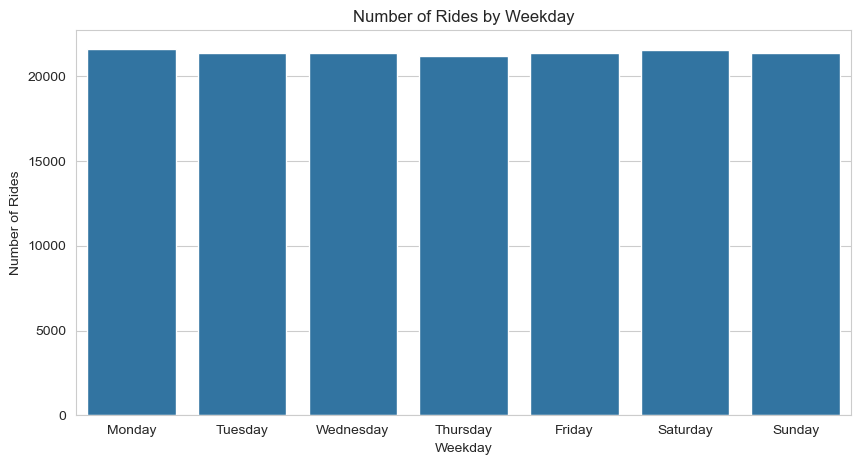

In [27]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=rides_by_weekday,
    x="weekday",
    y="rides"
)

plt.title("Number of Rides by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Rides")

plt.show()

### Спрос на поездки распределён относительно равномерно по дням недели.Это может говорить о стабильном использовании сервиса в течение всей недели.

# 6️. Advanced Analysis

## 6.1 Cancellation Rate by Vehicle Type

In [28]:
# считаем общее количество поездок и отмен по типу машины

cancel_vehicle = df.groupby("Vehicle Type").agg(

    total_rides=("Booking ID", "count"),
    cancelled_rides=("is_cancelled", "sum")

).reset_index()

In [29]:
# считаем процент отмен

cancel_vehicle["cancel_rate"] = (
    cancel_vehicle["cancelled_rides"] /
    cancel_vehicle["total_rides"] * 100
)

cancel_vehicle

,Vehicle Type,total_rides,cancelled_rides,cancel_rate
0,Auto,37419,9323,24.915150
1,Bike,22517,5652,25.101035
2,Go Mini,29806,7427,24.917802
3,Go Sedan,27141,6863,25.286467
4,Premier Sedan,18111,4516,24.935122
5,Uber XL,4449,1089,24.477411
6,eBike,10557,2630,24.912380


### Доля отмен по различным типам автомобилей отличается незначительно.  Это указывает на то, что проблема отмен скорее связана с операционными факторами, такими как ожидание или доступность водителей, а не с конкретным типом транспорта.

## 6.2 Demand Heatmap by Hour and Weekday

In [30]:
# создаём таблицу для heatmap

heatmap_data = df.pivot_table(

    index="weekday",
    columns="hour",
    values="Booking ID",
    aggfunc="count"

)

heatmap_data

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
Friday,180,187,190,203,204,379,585,766,984,1168,...,1043,1156,1409,1542,1767,1576,1371,1107,762,362
Monday,204,209,206,203,183,446,594,770,1026,1204,...,1006,1166,1394,1578,1835,1564,1418,1215,728,409
Saturday,195,201,174,190,201,412,593,776,965,1158,...,1036,1168,1356,1604,1800,1559,1380,1171,789,422
Sunday,200,192,182,204,193,366,566,794,981,1201,...,993,1117,1394,1592,1756,1640,1313,1193,790,370
Thursday,207,197,186,197,170,396,575,774,937,1148,...,987,1227,1357,1583,1687,1547,1364,1142,783,390
Tuesday,179,186,206,206,185,418,626,795,1026,1141,...,1003,1198,1329,1539,1763,1596,1372,1166,798,381
Wednesday,208,188,195,180,185,369,621,775,942,1214,...,963,1170,1394,1606,1789,1565,1412,1109,791,428


### Heatmap показывает, что наибольшая активность пользователей наблюдается в дневные и вечерние часы. Ночные и ранние утренние периоды характеризуются значительно меньшим количеством поездок.

## 6.3 Top Pickup Locations

In [31]:
# анализируем популярные точки посадки

pickup_analysis = df.groupby("Pickup Location").agg(

    total_rides=("Booking ID", "count"),
    cancelled_rides=("is_cancelled", "sum")

).reset_index()

In [32]:
# считаем процент отмен

pickup_analysis["cancel_rate"] = (

    pickup_analysis["cancelled_rides"] /
    pickup_analysis["total_rides"] * 100

)

# выводим топ 10 локаций

pickup_analysis.sort_values("total_rides", ascending=False).head(10)

,Pickup Location,total_rides,cancelled_rides,cancel_rate
80,Khandsa,949,226,23.814542
16,Barakhamba Road,946,230,24.312896
141,Saket,931,249,26.745435
13,Badarpur,921,231,25.081433
124,Pragati Maidan,920,248,26.956522
88,Madipur,919,212,23.068553
0,AIIMS,918,236,25.708061
96,Mehrauli,915,224,24.480874
34,Dwarka Sector 21,914,227,24.835886
120,Pataudi Chowk,907,215,23.704520


### Некоторые точки посадки генерируют значительно больше заказов, чем другие. Это может указывать на районы с высокой транспортной активностью или большой концентрацией пользователей сервиса.

## 6.4 Waiting Time vs Cancellation

In [33]:
# смотрим среднее время ожидания для разных статусов поездок

wait_analysis = df.groupby("Booking Status")[["Avg VTAT","Avg CTAT"]].mean()

wait_analysis

,Avg VTAT,Avg CTAT
Booking Status,,
Cancelled by Customer,12.512381,NaN
Cancelled by Driver,7.501952,NaN
Completed,8.511878,30.034772
Incomplete,6.013744,20.003233
No Driver Found,NaN,NaN


### Среднее время ожидания у отменённых поездок выше, чем у завершённых.  Это подтверждает гипотезу о том, что увеличение времени ожидания повышает вероятность отмены заказа клиентом.

## 6.5 Cancellation Reasons Analysis

In [34]:
# анализ причин отмен со стороны клиента
customer_cancel = df["Reason for cancelling by Customer"].value_counts()
customer_cancel

Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155
Name: count, dtype: int64

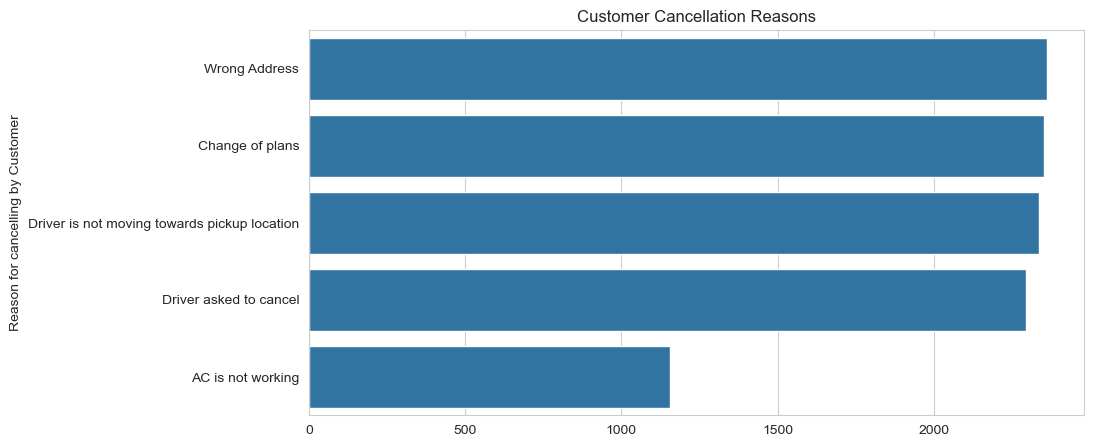

In [35]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=customer_cancel.values,
    y=customer_cancel.index
)

plt.title("Customer Cancellation Reasons")

plt.show()

In [36]:
# анализ причин отмен со стороны водителя
driver_cancel = df["Driver Cancellation Reason"].value_counts()
driver_cancel

Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686
Name: count, dtype: int64

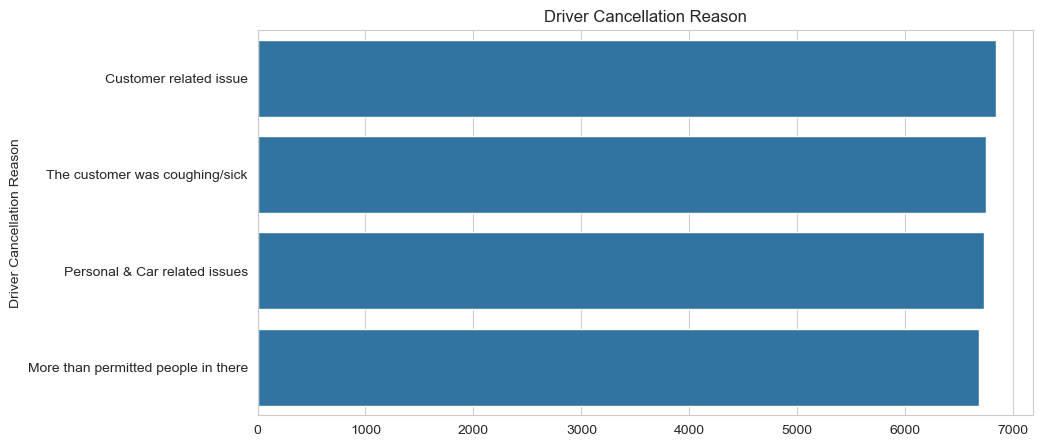

In [37]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=driver_cancel.values,
    y=driver_cancel.index
)

plt.title("Driver Cancellation Reason")

plt.show()

## 6.6 No Driver Found Analysis 

In [38]:
# фильтруем такие поездки

no_driver = df[df["Booking Status"] == "No Driver Found"]

no_driver.shape

(10500, 30)

In [39]:
no_driver_by_hour = no_driver.groupby("hour").size()

no_driver_by_hour

hour
0      93
1     110
2     107
3      99
4      89
5     187
6     308
7     387
8     477
9     588
10    647
11    601
12    529
13    373
14    466
15    547
16    696
17    749
18    891
19    766
20    674
21    553
22    385
23    178
dtype: int64

In [40]:
no_driver_locations = no_driver["Pickup Location"].value_counts().head(10)

no_driver_locations

Pickup Location
Old Gurgaon      83
Pataudi Chowk    80
Paharganj        79
Greater Noida    77
Vinobapuri       76
Rohini West      75
Dwarka Mor       72
Pitampura        72
Mehrauli         71
Udyog Bhawan     71
Name: count, dtype: int64

## 6.7 Ride Price Distribution

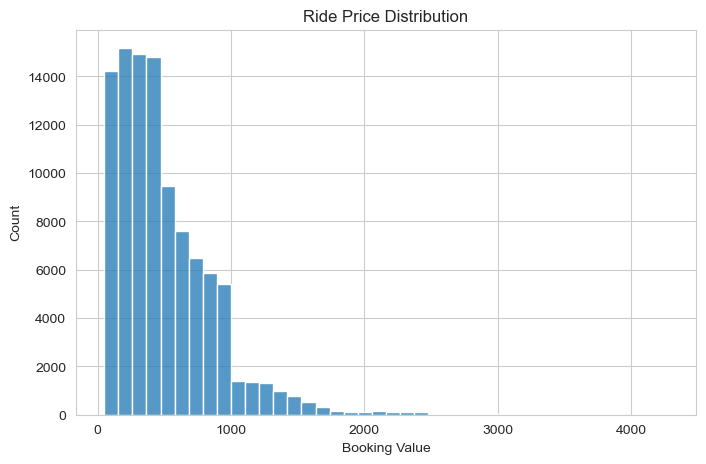

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(df["Booking Value"], bins=40)

plt.title("Ride Price Distribution")

plt.xlabel("Booking Value")

plt.show()

### Самые дорогие поездки

In [42]:
df.sort_values("Booking Value", ascending=False).head(10)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Payment Method,datetime,hour,weekday,month,is_weekend,is_completed,is_cancelled,is_unsuccessful,time_of_day
7450,2024-10-05,05:09:13,"""CNR7954315""",Completed,"""CID2706299""",Go Mini,Saidulajab,Netaji Subhash Place,9.5,17.2,...,UPI,2024-10-05 05:09:13,5,Saturday,10,True,1,0,0,Morning
83506,2024-08-25,18:35:03,"""CNR1798489""",Completed,"""CID4843078""",Bike,Ashram,Patel Chowk,14.2,41.5,...,Debit Card,2024-08-25 18:35:03,18,Sunday,8,True,1,0,0,Evening
2731,2024-05-15,10:11:36,"""CNR8487909""",Completed,"""CID2978596""",Auto,Welcome,Jama Masjid,6.6,15.6,...,UPI,2024-05-15 10:11:36,10,Wednesday,5,False,1,0,0,Morning
90418,2024-08-25,17:02:46,"""CNR5182516""",Completed,"""CID5235759""",Auto,Subhash Nagar,Laxmi Nagar,14.0,21.8,...,Uber Wallet,2024-08-25 17:02:46,17,Sunday,8,True,1,0,0,Evening
7116,2024-07-13,17:56:05,"""CNR7356012""",Completed,"""CID5789715""",Go Mini,IMT Manesar,Sarojini Nagar,9.3,44.0,...,Cash,2024-07-13 17:56:05,17,Saturday,7,True,1,0,0,Evening
43469,2024-09-14,16:20:32,"""CNR8849175""",Completed,"""CID9539119""",Go Mini,Ashok Vihar,Basai Dhankot,10.6,32.6,...,UPI,2024-09-14 16:20:32,16,Saturday,9,True,1,0,0,Afternoon
21011,2024-12-21,21:51:46,"""CNR5553074""",Completed,"""CID2674107""",eBike,GTB Nagar,Narsinghpur,8.9,15.1,...,UPI,2024-12-21 21:51:46,21,Saturday,12,True,1,0,0,Evening
32935,2024-07-21,22:42:15,"""CNR8715944""",Completed,"""CID1753183""",Go Sedan,Karol Bagh,Pitampura,12.4,39.6,...,UPI,2024-07-21 22:42:15,22,Sunday,7,True,1,0,0,Night
117985,2024-12-28,04:17:44,"""CNR7652202""",Completed,"""CID8107092""",Auto,AIIMS,Bhikaji Cama Place,5.3,22.8,...,Cash,2024-12-28 04:17:44,4,Saturday,12,True,1,0,0,Night
90667,2024-04-14,15:23:28,"""CNR8875064""",Completed,"""CID6777086""",Go Sedan,Dwarka Mor,Seelampur,11.5,34.1,...,UPI,2024-04-14 15:23:28,15,Sunday,4,True,1,0,0,Afternoon


### Самые длинные поездки

In [43]:
df.sort_values("Ride Distance", ascending=False).head(10)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Payment Method,datetime,hour,weekday,month,is_weekend,is_completed,is_cancelled,is_unsuccessful,time_of_day
145409,2024-02-06,17:06:47,"""CNR7472914""",Completed,"""CID5783983""",Go Mini,Kashmere Gate,Vaishali,8.2,36.5,...,UPI,2024-02-06 17:06:47,17,Tuesday,2,False,1,0,0,Evening
85964,2024-05-02,22:57:47,"""CNR4848846""",Completed,"""CID8966462""",Auto,Vishwavidyalaya,Hauz Rani,6.7,31.1,...,Cash,2024-05-02 22:57:47,22,Thursday,5,False,1,0,0,Night
119632,2024-12-15,19:37:24,"""CNR1476833""",Completed,"""CID3994793""",Auto,Faridabad Sector 15,Ardee City,14.7,35.9,...,Uber Wallet,2024-12-15 19:37:24,19,Sunday,12,True,1,0,0,Evening
40358,2024-07-15,11:14:48,"""CNR7401745""",Completed,"""CID7727573""",Bike,Nawada,Barakhamba Road,12.9,15.3,...,Cash,2024-07-15 11:14:48,11,Monday,7,False,1,0,0,Morning
88732,2024-11-25,10:48:20,"""CNR7988195""",Completed,"""CID2323632""",Go Mini,Bhikaji Cama Place,Gurgaon Railway Station,13.9,21.5,...,Credit Card,2024-11-25 10:48:20,10,Monday,11,False,1,0,0,Morning
5480,2024-01-04,20:25:36,"""CNR7816971""",Completed,"""CID8369298""",Go Sedan,Paharganj,Narsinghpur,5.1,40.5,...,Cash,2024-01-04 20:25:36,20,Thursday,1,False,1,0,0,Evening
81910,2024-08-17,17:38:18,"""CNR8839244""",Completed,"""CID4791320""",Go Sedan,Okhla,Malviya Nagar,11.6,36.8,...,UPI,2024-08-17 17:38:18,17,Saturday,8,True,1,0,0,Evening
72284,2024-10-17,15:21:19,"""CNR8388161""",Completed,"""CID1617900""",Go Sedan,Kherki Daula Toll,Kadarpur,3.6,43.0,...,UPI,2024-10-17 15:21:19,15,Thursday,10,False,1,0,0,Afternoon
86963,2024-10-31,15:44:40,"""CNR9240521""",Completed,"""CID3807531""",Auto,Old Gurgaon,Kashmere Gate ISBT,13.3,31.5,...,Uber Wallet,2024-10-31 15:44:40,15,Thursday,10,False,1,0,0,Afternoon
59334,2024-05-30,17:10:00,"""CNR8648930""",Completed,"""CID6308235""",Premier Sedan,Saidulajab,Chhatarpur,12.0,18.1,...,Cash,2024-05-30 17:10:00,17,Thursday,5,False,1,0,0,Evening


# 7. Visualization

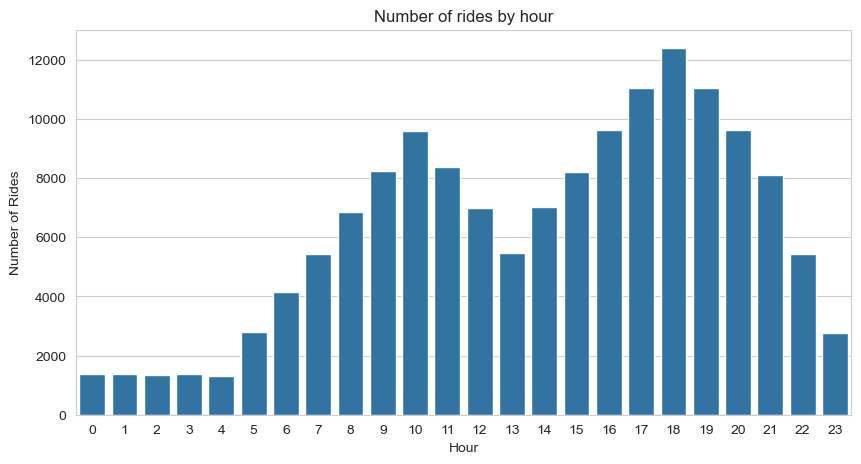

In [44]:
# график количества поездок по часам

plt.figure(figsize=(10,5))

sns.barplot(
    data=rides_by_hour,
    x="hour",
    y="rides"
)

plt.title("Number of rides by hour")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.show()

### Количество поездок начинает расти после 6:00 и достигает пика в вечерние часы, особенно около 18:00. Это может быть связано с рабочими поездками и возвращением людей домой после окончания рабочего дня.

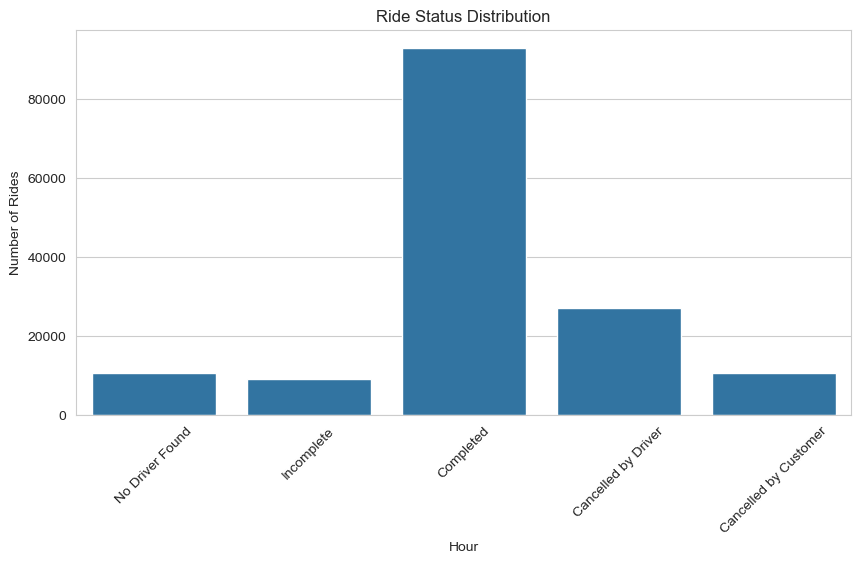

In [45]:
# распределение статусов поездок

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Booking Status"
)

plt.xticks(rotation=45)

plt.title("Ride Status Distribution")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.show()

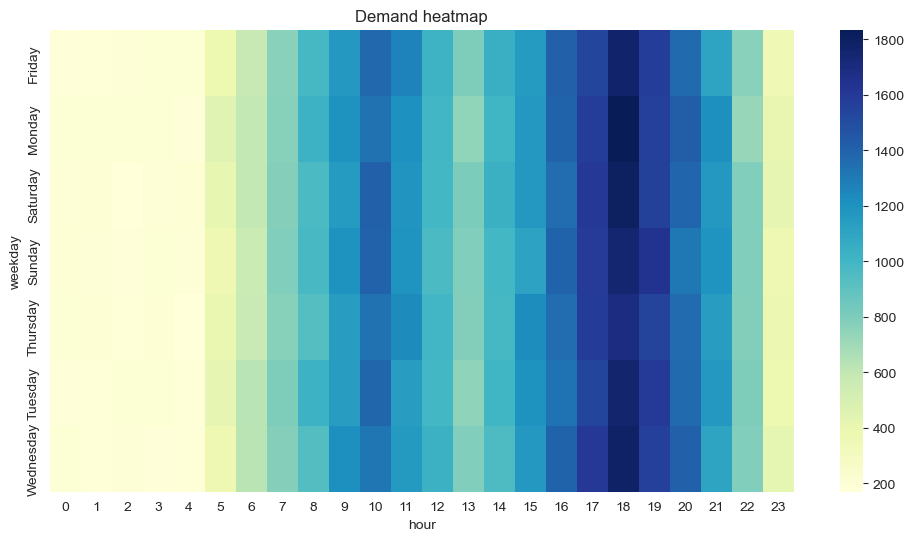

In [46]:
# heatmap спроса

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Demand heatmap")

plt.show()

### Heatmap подтверждает, что основной спрос концентрируется в дневные и вечерние часы, особенно с 9:00 до 11:00 и с 17:00 до 19:00. Ночные интервалы характеризуются минимальным количеством поездок.

# 8. Conclusions and Business Recommendations
## Бизнес-рекомендации

1. Увеличить количество доступных водителей в часы пик, особенно вечером.
2. Оптимизировать распределение водителей в наиболее загруженных районах.
3. Сократить время ожидания автомобиля, чтобы снизить долю отмен поездок.
4. Провести дополнительный анализ причин отмен со стороны водителей и клиентов.

# 9. Correlation Analysis
В этом разделе анализируются корреляции между числовыми признаками датасета.
Это позволяет понять, какие показатели связаны между собой.

Например:
• влияет ли дистанция поездки на стоимость
• связана ли стоимость с временем ожидания
• есть ли взаимосвязь между рейтингами

In [47]:
# выбираем только числовые столбцы

numeric_columns = df.select_dtypes(include="number")

numeric_columns.head()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating,hour,month,is_completed,is_cancelled,is_unsuccessful
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,3,0,0,1
1,4.9,14.0,NaN,NaN,1.0,237.0,5.73,NaN,NaN,18,11,0,0,1
2,13.4,25.8,NaN,NaN,NaN,627.0,13.58,4.9,4.9,8,8,1,0,0
3,13.1,28.5,NaN,NaN,NaN,416.0,34.02,4.6,5.0,17,10,1,0,0
4,5.3,19.6,NaN,NaN,NaN,737.0,48.21,4.1,4.3,22,9,1,0,0


In [48]:
# считаем матрицу корреляций

corr_cols = [
    "Avg VTAT", "Avg CTAT", "Booking Value",
    "Ride Distance", "Driver Ratings",
    "Customer Rating", "hour", "month"
]

corr_matrix = df[corr_cols].corr()

## Визуализация корреляций

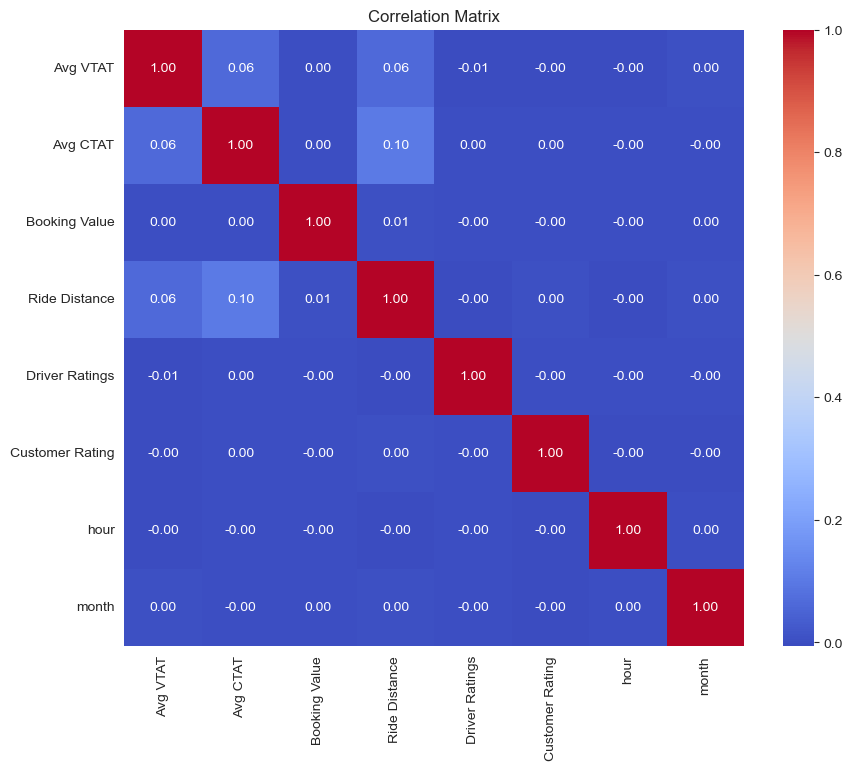

In [49]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## На основе корреляционной матрицы можно сделать следующие наблюдения:

• стоимость поездки положительно коррелирует с дистанцией
• некоторые показатели времени ожидания могут быть связаны с отменами
• рейтинги водителей и клиентов имеют слабую корреляцию с другими переменными

## 10. Ride Performance Analysis


### 9.1 Распределение дистанции поездок

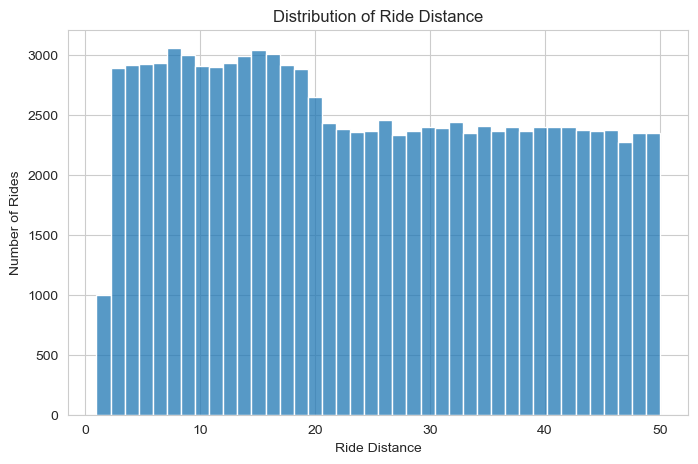

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Ride Distance"],
    bins=40
)

plt.title("Distribution of Ride Distance")
plt.xlabel("Ride Distance")
plt.ylabel("Number of Rides")

plt.show()


**Вывод** Большинство поездок имеют небольшую дистанцию. Это говорит о том, что сервис чаще используется для коротких городских поездок.

### 9.2 Распределение стоимости поездок

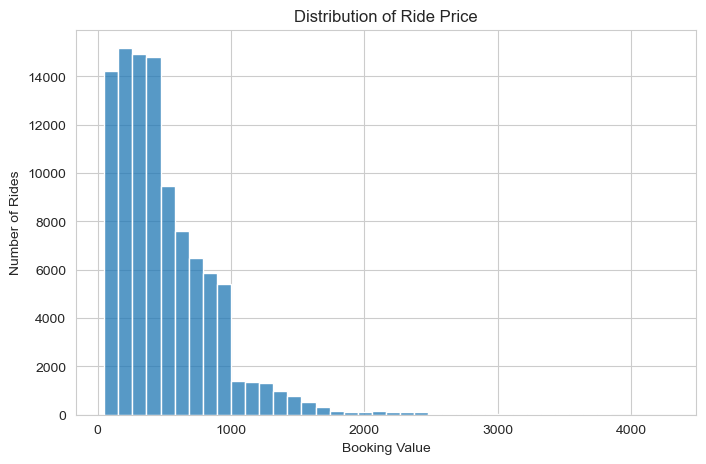

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Booking Value"],
    bins=40
)

plt.title("Distribution of Ride Price")
plt.xlabel("Booking Value")
plt.ylabel("Number of Rides")

plt.show()


**Вывод** Распределение стоимости поездок показывает,что большинство поездок находятся в низком ценовом диапазоне.

### 9.3 Связь расстояния и стоимости

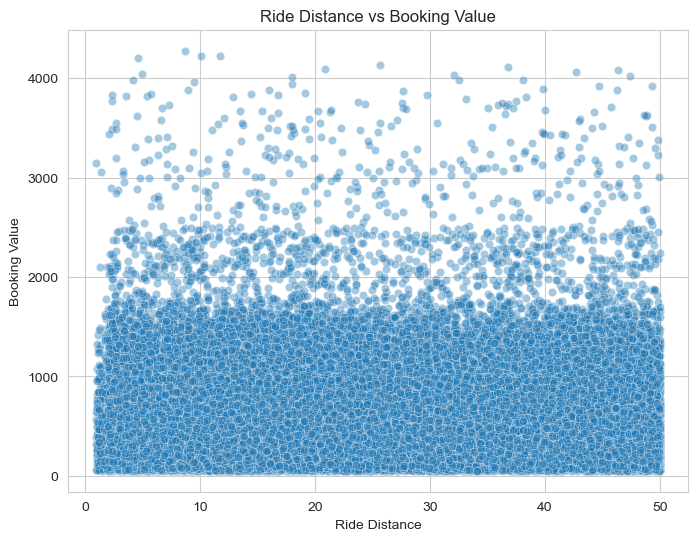

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Ride Distance",
    y="Booking Value",
    alpha=0.4
)

plt.title("Ride Distance vs Booking Value")
plt.xlabel("Ride Distance")
plt.ylabel("Booking Value")

plt.show()


**Вывод** Стоимость поездки увеличивается с ростом расстояния,что соответствует ожидаемой модели ценообразования сервиса.

### 9.4 Топ самых дорогих поездок

In [53]:
df.sort_values("Booking Value", ascending=False).head(10)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Payment Method,datetime,hour,weekday,month,is_weekend,is_completed,is_cancelled,is_unsuccessful,time_of_day
7450,2024-10-05,05:09:13,"""CNR7954315""",Completed,"""CID2706299""",Go Mini,Saidulajab,Netaji Subhash Place,9.5,17.2,...,UPI,2024-10-05 05:09:13,5,Saturday,10,True,1,0,0,Morning
83506,2024-08-25,18:35:03,"""CNR1798489""",Completed,"""CID4843078""",Bike,Ashram,Patel Chowk,14.2,41.5,...,Debit Card,2024-08-25 18:35:03,18,Sunday,8,True,1,0,0,Evening
2731,2024-05-15,10:11:36,"""CNR8487909""",Completed,"""CID2978596""",Auto,Welcome,Jama Masjid,6.6,15.6,...,UPI,2024-05-15 10:11:36,10,Wednesday,5,False,1,0,0,Morning
90418,2024-08-25,17:02:46,"""CNR5182516""",Completed,"""CID5235759""",Auto,Subhash Nagar,Laxmi Nagar,14.0,21.8,...,Uber Wallet,2024-08-25 17:02:46,17,Sunday,8,True,1,0,0,Evening
7116,2024-07-13,17:56:05,"""CNR7356012""",Completed,"""CID5789715""",Go Mini,IMT Manesar,Sarojini Nagar,9.3,44.0,...,Cash,2024-07-13 17:56:05,17,Saturday,7,True,1,0,0,Evening
43469,2024-09-14,16:20:32,"""CNR8849175""",Completed,"""CID9539119""",Go Mini,Ashok Vihar,Basai Dhankot,10.6,32.6,...,UPI,2024-09-14 16:20:32,16,Saturday,9,True,1,0,0,Afternoon
21011,2024-12-21,21:51:46,"""CNR5553074""",Completed,"""CID2674107""",eBike,GTB Nagar,Narsinghpur,8.9,15.1,...,UPI,2024-12-21 21:51:46,21,Saturday,12,True,1,0,0,Evening
32935,2024-07-21,22:42:15,"""CNR8715944""",Completed,"""CID1753183""",Go Sedan,Karol Bagh,Pitampura,12.4,39.6,...,UPI,2024-07-21 22:42:15,22,Sunday,7,True,1,0,0,Night
117985,2024-12-28,04:17:44,"""CNR7652202""",Completed,"""CID8107092""",Auto,AIIMS,Bhikaji Cama Place,5.3,22.8,...,Cash,2024-12-28 04:17:44,4,Saturday,12,True,1,0,0,Night
90667,2024-04-14,15:23:28,"""CNR8875064""",Completed,"""CID6777086""",Go Sedan,Dwarka Mor,Seelampur,11.5,34.1,...,UPI,2024-04-14 15:23:28,15,Sunday,4,True,1,0,0,Afternoon


**Вывод** Самые дорогие поездки связаны с наибольшими расстояниями,что подтверждает зависимость стоимости от длины маршрута.

## 10. Demand vs Supply Imbalance Analysis

### 10.1 Сравним статусы поездок по часам

In [54]:
status_hour = df.groupby(["hour","Booking Status"]).size().unstack()

status_hour


Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
hour,,,,,
0,92,248,858,82,93
1,94,250,828,78,110
2,75,222,853,82,107
3,92,263,860,69,99
4,98,240,830,64,89
5,204,532,1715,148,187
6,306,699,2609,238,308
7,376,1006,3346,335,387
8,493,1221,4267,403,477


### 10.2 Визуализация

<Figure size 1200x600 with 0 Axes>

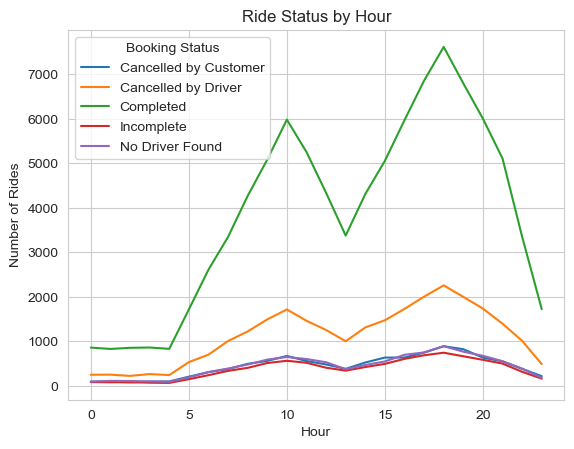

In [55]:
plt.figure(figsize=(12,6))

status_hour.plot(kind="line")

plt.title("Ride Status by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")

plt.show()


### 10.3 Отдельно посмотрим No Driver Found

In [56]:
no_driver_hour = (
    df[df["Booking Status"] == "No Driver Found"]
    .groupby("hour")
    .size()
)

no_driver_hour


hour
0      93
1     110
2     107
3      99
4      89
5     187
6     308
7     387
8     477
9     588
10    647
11    601
12    529
13    373
14    466
15    547
16    696
17    749
18    891
19    766
20    674
21    553
22    385
23    178
dtype: int64

### 10.5 График

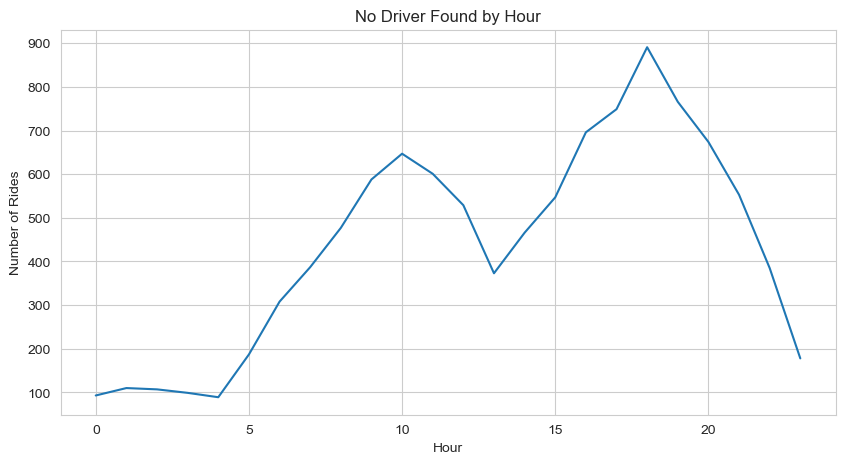

In [57]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=no_driver_hour.index,
    y=no_driver_hour.values
)

plt.title("No Driver Found by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")

plt.show()


**Вывод** Количество случаев "No Driver Found" увеличивается в периоды повышенного спроса на поездки.Это может указывать на дефицит водителей в часы пик,когда спрос на сервис превышает доступное предложение.

## 11 Peak Hour Performance Analysis

### 11.1 Определим часы пик

In [58]:
rides_by_hour = df.groupby("hour").size().reset_index(name="rides")

rides_by_hour.sort_values("rides", ascending=False).head()


,hour,rides
18,18,12397
19,19,11047
17,17,11044
16,16,9633
20,20,9630


### 11.2 Отфильтруем поездки в часы пик

In [59]:
peak_hours = [17,18,19]

peak_data = df[df["hour"].isin(peak_hours)]

peak_data.head()


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Payment Method,datetime,hour,weekday,month,is_weekend,is_completed,is_cancelled,is_unsuccessful,time_of_day
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,UPI,2024-11-29 18:01:39,18,Friday,11,False,0,0,1,Evening
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,UPI,2024-10-21 17:17:25,17,Monday,10,False,1,0,0,Evening
7,2024-03-19,17:37:37,"""CNR6568000""",Completed,"""CID8610436""",Auto,Mayur Vihar,Cyber Hub,12.1,16.5,...,UPI,2024-03-19 17:37:37,17,Tuesday,3,False,1,0,0,Evening
9,2024-12-16,19:06:48,"""CNR7721892""",Incomplete,"""CID5214275""",Auto,Rohini,Adarsh Nagar,6.1,26.0,...,Cash,2024-12-16 19:06:48,19,Monday,12,False,0,0,1,Evening
13,2024-09-11,19:29:39,"""CNR2987763""",Completed,"""CID2669710""",Go Mini,Malviya Nagar,Ghitorni Village,12.2,28.2,...,UPI,2024-09-11 19:29:39,19,Wednesday,9,False,1,0,0,Evening


### 11.3 Посмотрим распределение статусов

In [60]:
peak_status = peak_data["Booking Status"].value_counts()

peak_status


Booking Status
Completed                21275
Cancelled by Driver       6258
Cancelled by Customer     2457
No Driver Found           2406
Incomplete                2092
Name: count, dtype: int64

### 11.4 Визуализация

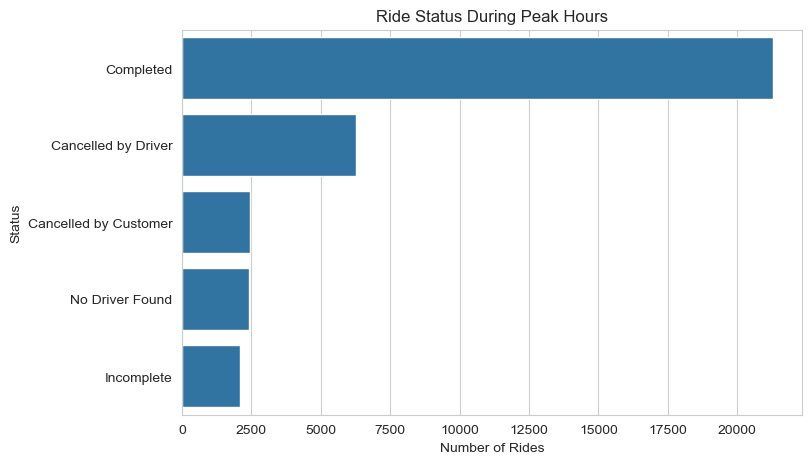

In [61]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=peak_status.values,
    y=peak_status.index
)

plt.title("Ride Status During Peak Hours")
plt.xlabel("Number of Rides")
plt.ylabel("Status")

plt.show()


### 11.5 Проверим среднее время ожидания

In [62]:
peak_wait = peak_data[["Avg VTAT","Avg CTAT"]].mean()

peak_wait


Avg VTAT     8.424269
Avg CTAT    29.176206
dtype: float64

In [ ]:

**Вывод**
В часы пик количество поездок значительно возрастает.  
В эти периоды также наблюдается рост отмен и случаев "No Driver Found".
Это может указывать на дефицит водителей и увеличение времени ожидания при высокой нагрузке на сервис.

## Основные выводы

1. Спрос на поездки распределяется неравномерно в течение суток и достигает пика в вечерние часы.

2. Большая часть поездок завершается успешно, однако значительная доля заказов отменяется или не выполняется.

3. Уровень отмен практически не зависит от типа автомобиля.

4. Наиболее загруженные точки посадки концентрируют основной поток заказов.

5. Увеличение времени ожидания связано с ростом количества отмен поездок.